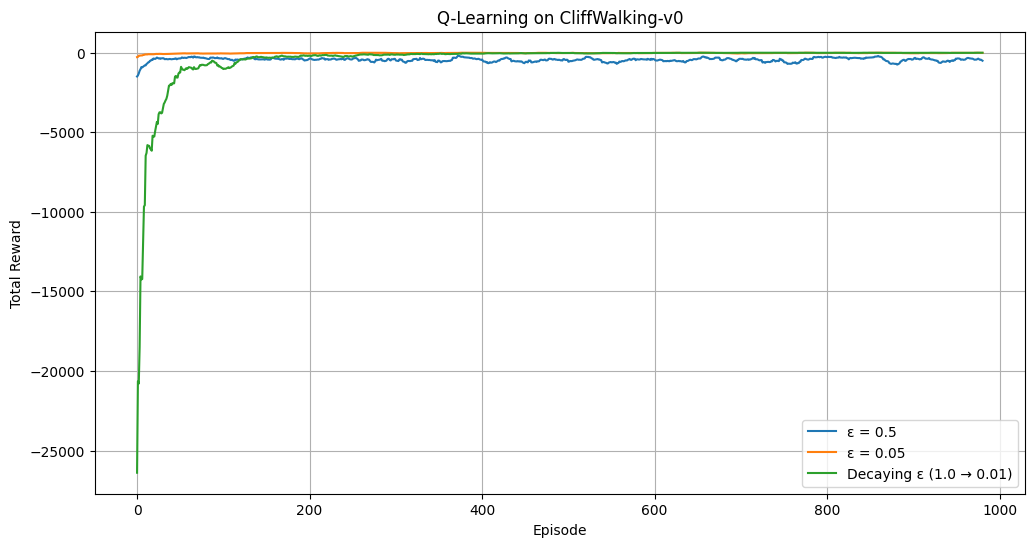

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Q-Learning Function
# -----------------------------
def q_learning(env, episodes, alpha, gamma,
               epsilon_start,
               epsilon_end=None,
               decay=False):

    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))

    rewards_per_episode = []

    for episode in range(episodes):

        state, _ = env.reset()
        done = False
        total_reward = 0

        # Epsilon value
        if decay:
            epsilon = max(
                epsilon_end,
                epsilon_start * (0.995 ** episode)
            )
        else:
            epsilon = epsilon_start

        while not done:

            # Epsilon-Greedy Action Selection
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated

            # Q-Learning Update
            Q[state, action] = Q[state, action] + alpha * (
                reward
                + gamma * np.max(Q[next_state])
                - Q[state, action]
            )

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode


# -----------------------------
# Environment
# -----------------------------
env = gym.make("CliffWalking-v1")

episodes = 1000
alpha = 0.1
gamma = 0.99

# -----------------------------
# Agent 1: High Exploration
# -----------------------------
Q_high, rewards_high = q_learning(
    env,
    episodes,
    alpha,
    gamma,
    epsilon_start=0.5,
    decay=False
)

# -----------------------------
# Agent 2: Low Exploration
# -----------------------------
Q_low, rewards_low = q_learning(
    env,
    episodes,
    alpha,
    gamma,
    epsilon_start=0.05,
    decay=False
)

# -----------------------------
# Agent 3: Decaying Exploration
# -----------------------------
Q_decay, rewards_decay = q_learning(
    env,
    episodes,
    alpha,
    gamma,
    epsilon_start=1.0,
    epsilon_end=0.01,
    decay=True
)

# -----------------------------
# Moving Average Function
# -----------------------------
def moving_average(data, window=20):
    return np.convolve(
        data,
        np.ones(window) / window,
        mode='valid'
    )

# -----------------------------
# Plot Results
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(
    moving_average(rewards_high),
    label="ε = 0.5"
)

plt.plot(
    moving_average(rewards_low),
    label="ε = 0.05"
)

plt.plot(
    moving_average(rewards_decay),
    label="Decaying ε (1.0 → 0.01)"
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning on CliffWalking-v0")
plt.legend()
plt.grid(True)

plt.show()